## Imports

In [11]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

## Data Exploration
An overview of summary statistic of the dataset and create variables and functions for the analysis.

In [12]:
df = pd.read_csv("C:\\Users\\karoo\\3\\southwest\\flight-delays-southwest\\dataset\\sampled.csv")

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 29 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Year                       1000000 non-null  int64  
 1   Month                      1000000 non-null  int64  
 2   DayofMonth                 1000000 non-null  int64  
 3   FlightDate                 1000000 non-null  object 
 4   Marketing_Airline_Network  1000000 non-null  object 
 5   OriginCityName             1000000 non-null  object 
 6   DestCityName               1000000 non-null  object 
 7   CRSDepTime                 1000000 non-null  int64  
 8   DepTime                    1000000 non-null  float64
 9   DepDelay                   1000000 non-null  float64
 10  DepDelayMinutes            1000000 non-null  float64
 11  TaxiOut                    1000000 non-null  float64
 12  WheelsOff                  1000000 non-null  float64
 13  WheelsOn     

In [14]:
df.reset_index(drop = True, inplace = True)
df

,Year,Month,DayofMonth,FlightDate,Marketing_Airline_Network,OriginCityName,DestCityName,CRSDepTime,DepTime,DepDelay,...,CRSElapsedTime,ActualElapsedTime,AirTime,Distance,DistanceGroup,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,2018,5,13,2018-05-13,WN,"Newark, NJ","Fort Lauderdale, FL",1105,1139.0,34.0,...,182.0,199.0,146.0,1065.0,5,0.0,0.0,17.0,0.0,34.0
1,2020,2,3,2020-02-03,WN,"Dallas/Fort Worth, TX","New York, NY",1707,1721.0,14.0,...,202.0,182.0,161.0,1389.0,6,0.0,0.0,0.0,0.0,0.0
2,2020,1,9,2020-01-09,WN,"Philadelphia, PA","Syracuse, NY",1650,1645.0,-5.0,...,72.0,61.0,44.0,228.0,1,0.0,0.0,0.0,0.0,0.0
3,2019,3,29,2019-03-29,WN,"Las Vegas, NV","Seattle, WA",2040,2028.0,-12.0,...,163.0,160.0,132.0,867.0,4,0.0,0.0,0.0,0.0,0.0
4,2020,3,7,2020-03-07,WN,"Dallas, TX","Birmingham, AL",1255,1331.0,36.0,...,100.0,84.0,72.0,587.0,3,20.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,2018,6,8,2018-06-08,WN,"Oklahoma City, OK","Chicago, IL",805,845.0,40.0,...,115.0,132.0,92.0,691.0,3,0.0,0.0,57.0,0.0,0.0
999996,2022,11,9,2022-11-09,WN,"Seattle, WA","Los Angeles, CA",1850,1848.0,-2.0,...,167.0,150.0,120.0,954.0,4,0.0,0.0,0.0,0.0,0.0
999997,2021,7,26,2021-07-26,WN,"Los Angeles, CA","Buffalo, NY",2353,2352.0,-1.0,...,291.0,309.0,266.0,2218.0,9,0.0,0.0,17.0,0.0,0.0
999998,2023,1,22,2023-01-22,WN,"Texarkana, AR","Dallas/Fort Worth, TX",1826,1816.0,-10.0,...,67.0,63.0,39.0,181.0,1,0.0,0.0,0.0,0.0,0.0


In [15]:
df.isnull().sum()
df.duplicated().sum()

0

In [43]:
df.columns 

Index(['dep_date', 'Marketing_Airline_Network', 'CarrierName', 'origin_city',
       'origin_state', 'dest_city', 'dest_state', 'CRS_dep_time', 'dep_time',
       'dep_delay', 'dep_delay_minutes', 'taxi_out', 'wheels_off', 'wheels_on',
       'taxi_in', 'CRS_arr_time', 'arr_time', 'arr_delay', 'arr_delay_minutes',
       'CRS_elapsed_time', 'actual_elapsed_time', 'air_time', 'distance',
       'distance_group', 'carrier_delay', 'weather_delay', 'NAS_delay',
       'security_delay', 'late_aircraft_delay'],
      dtype='object')

In [16]:
df.isnull().sum()

Year                         0
Month                        0
DayofMonth                   0
FlightDate                   0
Marketing_Airline_Network    0
OriginCityName               0
DestCityName                 0
CRSDepTime                   0
DepTime                      0
DepDelay                     0
DepDelayMinutes              0
TaxiOut                      0
WheelsOff                    0
WheelsOn                     0
TaxiIn                       0
CRSArrTime                   0
ArrTime                      0
ArrDelay                     0
ArrDelayMinutes              0
CRSElapsedTime               0
ActualElapsedTime            0
AirTime                      0
Distance                     0
DistanceGroup                0
CarrierDelay                 0
WeatherDelay                 0
NASDelay                     0
SecurityDelay                0
LateAircraftDelay            0
dtype: int64

## Rename columns

In [17]:
df = df.rename(columns = 
          {"FlightDate": "flight_date",
            "OriginCityName": "origin_city_name", 
            "DestCityName": "dest_city_name",
            "CRSDepTime": "CRS_dep_time",
            "DepTime": "dep_time",
            "DepDelay": "dep_delay",
            "DepDelayMinutes": "dep_delay_minutes",
            "TaxiOut": "taxi_out",
            "WheelsOff": "wheels_off",
            "WheelsOn": "wheels_on",
            "TaxiIn": "taxi_in",
            "CRSArrTime": "CRS_arr_time",
            "ArrTime": "arr_time",
            "ArrDelay": "arr_delay",
            "ArrDelayMinutes": "arr_delay_minutes",
            "CRSElapsedTime": "CRS_elapsed_time",
            "ActualElapsedTime": "actual_elapsed_time",
            "AirTime": "air_time",
            "Distance": "distance",
            "DistanceGroup": "distance_group",
            "CarrierDelay": "carrier_delay",
            "WeatherDelay": "weather_delay",
            "NASDelay": "NAS_delay",
            "SecurityDelay": "security_delay",
            "LateAircraftDelay": "late_aircraft_delay",
            "DayofMonth": "day_of_month"
         }).copy()

In [18]:
float_columns = df.select_dtypes(include=['float64']).columns
df[float_columns] = df[float_columns].astype('int64')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 29 columns):
 #   Column                     Non-Null Count    Dtype 
---  ------                     --------------    ----- 
 0   Year                       1000000 non-null  int64 
 1   Month                      1000000 non-null  int64 
 2   day_of_month               1000000 non-null  int64 
 3   flight_date                1000000 non-null  object
 4   Marketing_Airline_Network  1000000 non-null  object
 5   origin_city_name           1000000 non-null  object
 6   dest_city_name             1000000 non-null  object
 7   CRS_dep_time               1000000 non-null  int64 
 8   dep_time                   1000000 non-null  int64 
 9   dep_delay                  1000000 non-null  int64 
 10  dep_delay_minutes          1000000 non-null  int64 
 11  taxi_out                   1000000 non-null  int64 
 12  wheels_off                 1000000 non-null  int64 
 13  wheels_on                  1

In [19]:
df['dep_date'] = pd.to_datetime(df['flight_date'])

df.drop(['flight_date', 'Year', 'Month', 'day_of_month'], axis = 1, inplace = True)

df.head()

,Marketing_Airline_Network,origin_city_name,dest_city_name,CRS_dep_time,dep_time,dep_delay,dep_delay_minutes,taxi_out,wheels_off,wheels_on,...,actual_elapsed_time,air_time,distance,distance_group,carrier_delay,weather_delay,NAS_delay,security_delay,late_aircraft_delay,dep_date
0,WN,"Newark, NJ","Fort Lauderdale, FL",1105,1139,34,34,19,1158,1424,...,199,146,1065,5,0,0,17,0,34,2018-05-13
1,WN,"Dallas/Fort Worth, TX","New York, NY",1707,1721,14,14,13,1734,2115,...,182,161,1389,6,0,0,0,0,0,2020-02-03
2,WN,"Philadelphia, PA","Syracuse, NY",1650,1645,-5,0,13,1658,1742,...,61,44,228,1,0,0,0,0,0,2020-01-09
3,WN,"Las Vegas, NV","Seattle, WA",2040,2028,-12,0,17,2045,2257,...,160,132,867,4,0,0,0,0,0,2019-03-29
4,WN,"Dallas, TX","Birmingham, AL",1255,1331,36,36,9,1340,1452,...,84,72,587,3,20,0,0,0,0,2020-03-07


In [20]:
# Splitting OriginCityName
df[['origin_city', 'origin_state']] = df['origin_city_name'].str.split(', ', expand = True)

# Splitting DestCityName
df[['dest_city','dest_state']] = df['dest_city_name'].str.split(', ', expand = True)

# Dropping the original columns
df.drop(['origin_city_name', 'dest_city_name'], axis = 1, inplace = True)

df[['origin_city', 'origin_state', 'dest_city', 'dest_state']]

,origin_city,origin_state,dest_city,dest_state
0,Newark,NJ,Fort Lauderdale,FL
1,Dallas/Fort Worth,TX,New York,NY
2,Philadelphia,PA,Syracuse,NY
3,Las Vegas,NV,Seattle,WA
4,Dallas,TX,Birmingham,AL
...,...,...,...,...
999995,Oklahoma City,OK,Chicago,IL
999996,Seattle,WA,Los Angeles,CA
999997,Los Angeles,CA,Buffalo,NY
999998,Texarkana,AR,Dallas/Fort Worth,TX


In [21]:
df.loc[df['Marketing_Airline_Network'] == 'WN', 'CarrierName'] = 'Southwest Airlines'

In [22]:
final_columns = ['dep_date' ,'Marketing_Airline_Network', 'CarrierName', 'origin_city', 'origin_state', 'dest_city', 'dest_state',
                    'CRS_dep_time', 'dep_time',  'dep_delay', 'dep_delay_minutes', 'taxi_out', 'wheels_off', 
                    'wheels_on', 'taxi_in', 'CRS_arr_time', 'arr_time', 'arr_delay', 'arr_delay_minutes', 
                    'CRS_elapsed_time', 'actual_elapsed_time', 'air_time', 'distance', 'distance_group', 
                    'carrier_delay', 'weather_delay', 'NAS_delay', 'security_delay', 'late_aircraft_delay']

df = df[final_columns]

df.head()

,dep_date,Marketing_Airline_Network,CarrierName,origin_city,origin_state,dest_city,dest_state,CRS_dep_time,dep_time,dep_delay,...,CRS_elapsed_time,actual_elapsed_time,air_time,distance,distance_group,carrier_delay,weather_delay,NAS_delay,security_delay,late_aircraft_delay
0,2018-05-13,WN,Southwest Airlines,Newark,NJ,Fort Lauderdale,FL,1105,1139,34,...,182,199,146,1065,5,0,0,17,0,34
1,2020-02-03,WN,Southwest Airlines,Dallas/Fort Worth,TX,New York,NY,1707,1721,14,...,202,182,161,1389,6,0,0,0,0,0
2,2020-01-09,WN,Southwest Airlines,Philadelphia,PA,Syracuse,NY,1650,1645,-5,...,72,61,44,228,1,0,0,0,0,0
3,2019-03-29,WN,Southwest Airlines,Las Vegas,NV,Seattle,WA,2040,2028,-12,...,163,160,132,867,4,0,0,0,0,0
4,2020-03-07,WN,Southwest Airlines,Dallas,TX,Birmingham,AL,1255,1331,36,...,100,84,72,587,3,20,0,0,0,0


## Analyzing departure delay
- Distribution
- Dep delay by time of the day
- Dep delay through the years


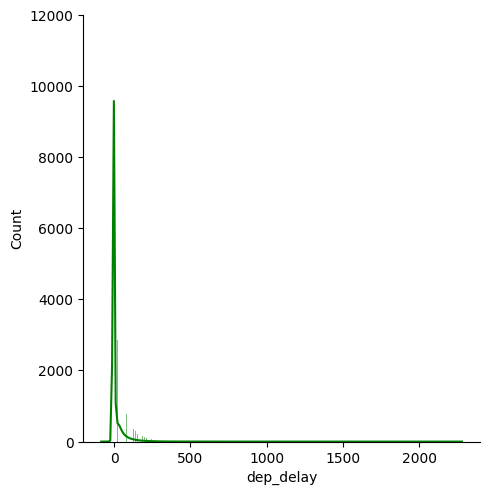

In [42]:
dep_delay = df[['dep_date', 'Marketing_Airline_Network', 'CarrierName', 'origin_city', 'origin_state', 'CRS_dep_time', 
                     'dep_time', 'dep_delay']]

sns.displot(dep_delay['dep_delay'], color='g', kde=True)
plt.ylim(0,12000)
plt.show()

In [24]:
print("Skewness: %f" %dep_delay['dep_delay'].skew())
print("Kurtosis: %f" %dep_delay['dep_delay'].kurt())

Skewness: 9.951043
Kurtosis: 171.303943


From histogram and by skewness and kurtosis index, the departure delays are mostly located to the right side of the graph with a very long tail to the right. The majority of delays are short and the longer delays, while unusual are more heavily loaded in time.

Text(0.5, 1.0, 'Departure Delay by Time of the Day')

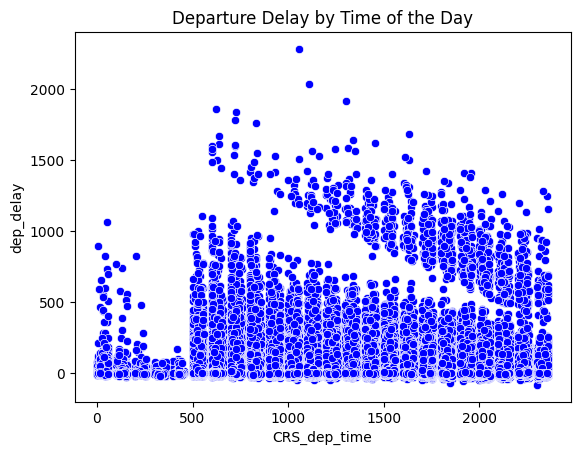

In [25]:
sns.scatterplot(x='CRS_dep_time', y='dep_delay', data=dep_delay, color='b')
plt.title('Departure Delay by Time of the Day')

The duration of departure delay w.r.t. time of scheduled departure increases in the morning and then slowly decreases towards the end of the day.

<Axes: xlabel='dep_date', ylabel='dep_delay'>

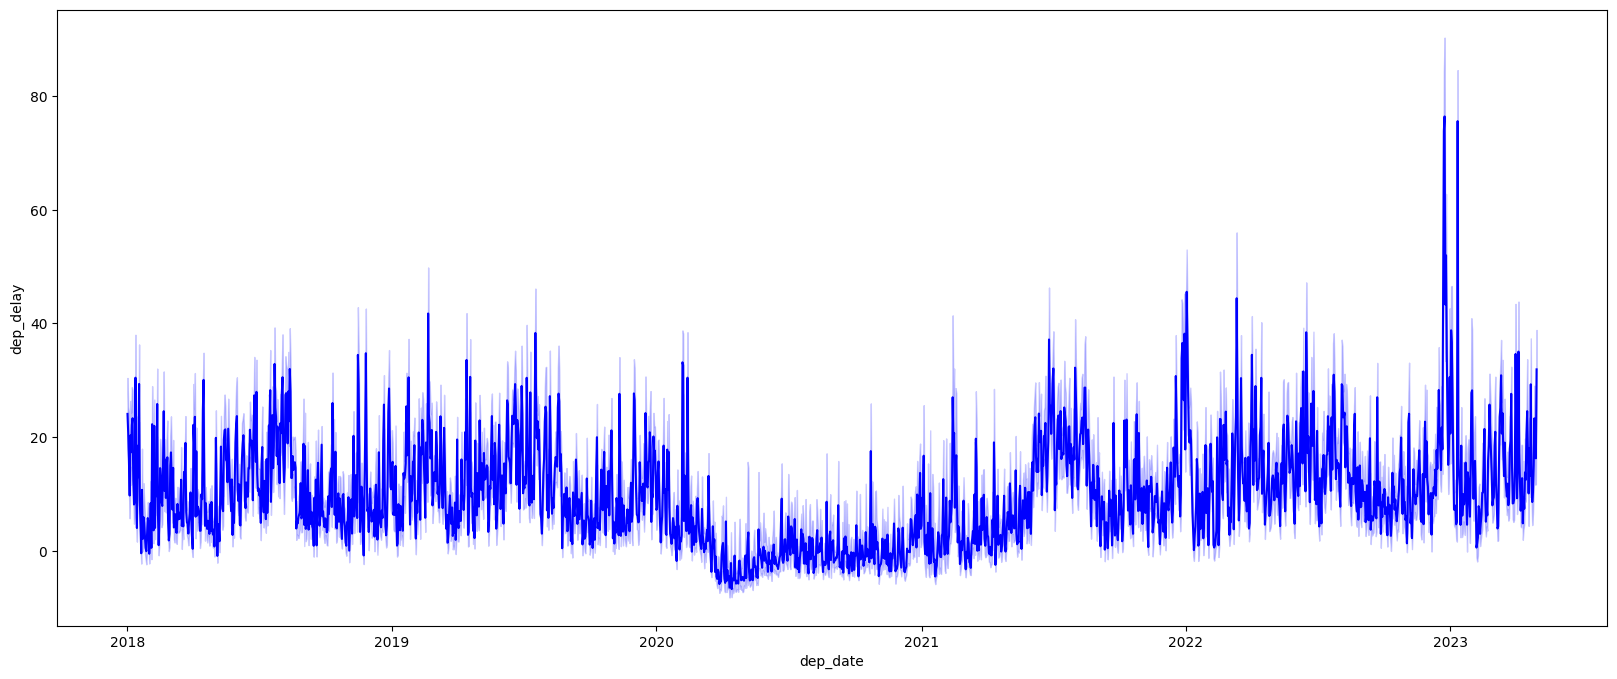

In [26]:
# departure delay through the years
plt.figure(figsize = (20,8))

sns.lineplot(data = dep_delay[['dep_date', 'dep_delay']], x = 'dep_date', y = 'dep_delay', color = 'b')

## Top cities with highest number of dep delay and avg dep delay

<Axes: xlabel='dep_delay', ylabel='origin_city'>

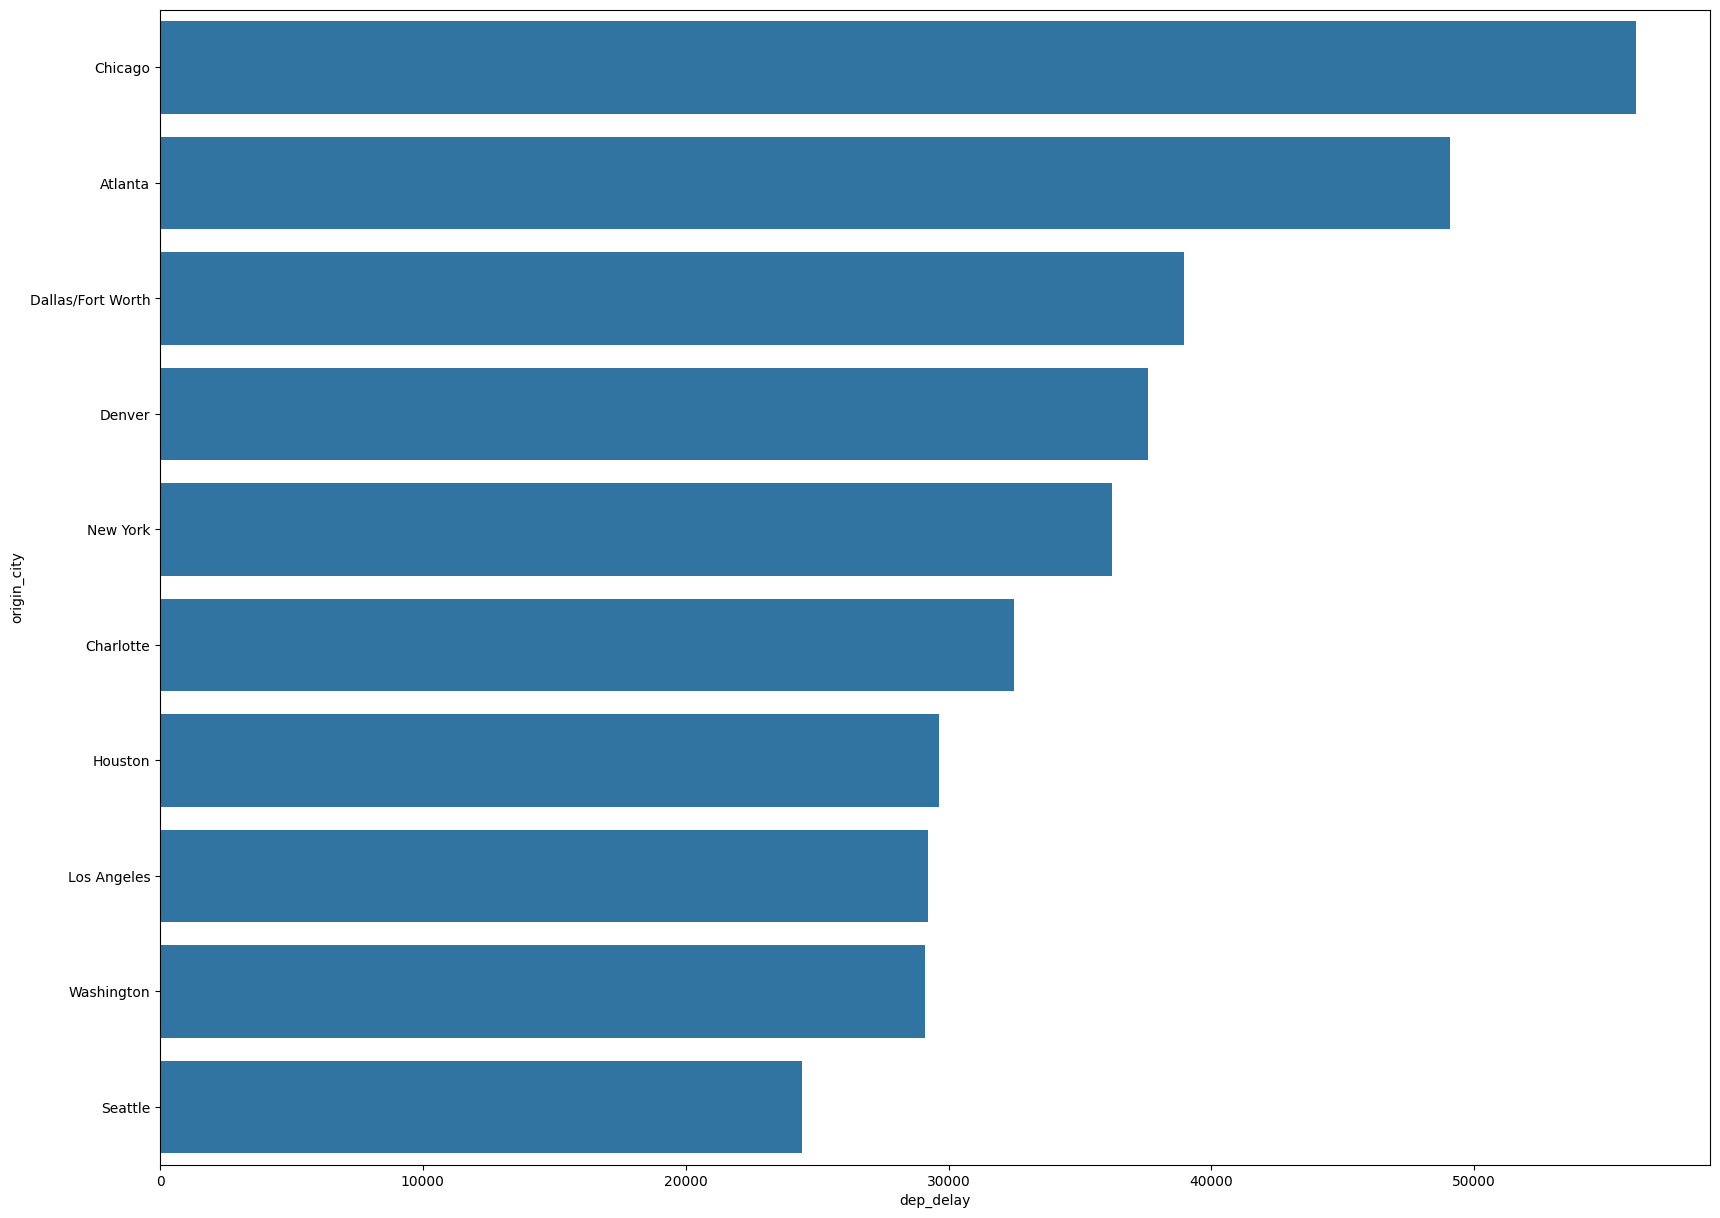

In [27]:
plt.figure(figsize = (20,15))
sns.barplot(data = dep_delay[['origin_city','dep_delay']].groupby(['origin_city']).count()
            .sort_values(by = 'dep_delay', ascending = False).head(10).reset_index(), 
            x = 'dep_delay', y = 'origin_city')

<Axes: xlabel='dep_delay', ylabel='origin_city'>

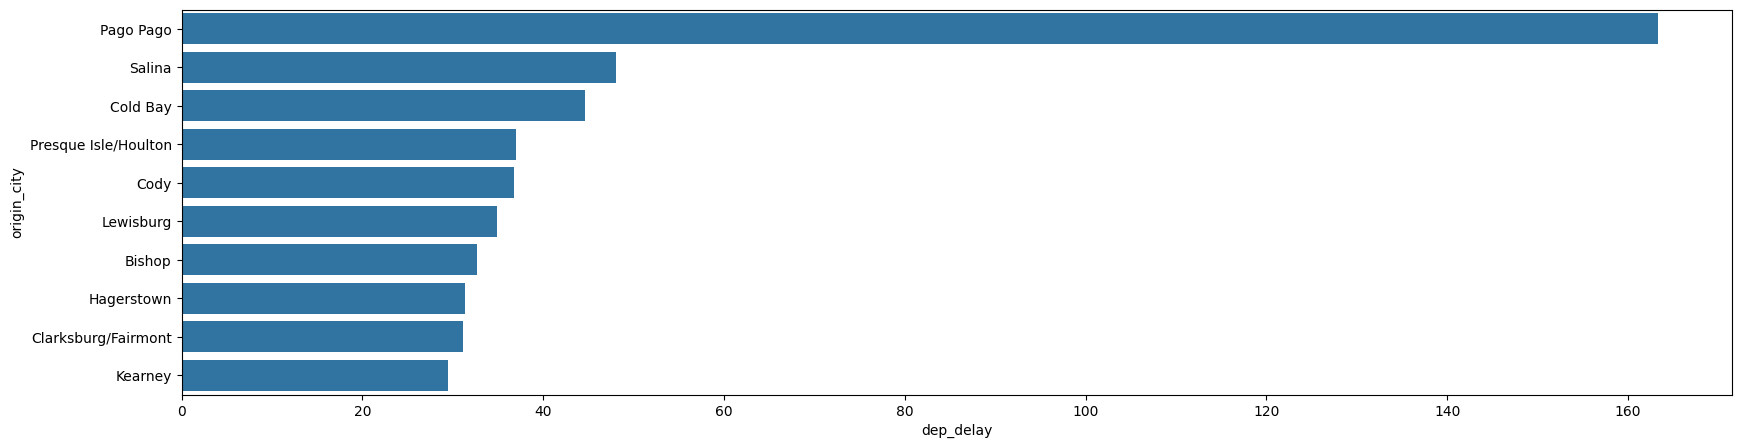

In [28]:
# top 10 cities with highest avg dep delay
plt.figure(figsize = (20,5))
sns.barplot(data = dep_delay[['origin_city','dep_delay']].groupby(['origin_city']).mean()
            .sort_values(by = 'dep_delay', ascending = False).head(10).reset_index(), 
            x = 'dep_delay', y = 'origin_city')

## Arrival delay
- arrival delay is sum of carrier, weather, nas, security, late arrival delay
- distribution check
- relationship between arrival delay and departure delay
- arrival delay w.r.t. scheduled daparture and arrival time
- arrival delay through the years
- arrival delay through months of the year

In [29]:
df.columns

Index(['dep_date', 'Marketing_Airline_Network', 'CarrierName', 'origin_city',
       'origin_state', 'dest_city', 'dest_state', 'CRS_dep_time', 'dep_time',
       'dep_delay', 'dep_delay_minutes', 'taxi_out', 'wheels_off', 'wheels_on',
       'taxi_in', 'CRS_arr_time', 'arr_time', 'arr_delay', 'arr_delay_minutes',
       'CRS_elapsed_time', 'actual_elapsed_time', 'air_time', 'distance',
       'distance_group', 'carrier_delay', 'weather_delay', 'NAS_delay',
       'security_delay', 'late_aircraft_delay'],
      dtype='object')

In [30]:
arr_delay = df[['dep_date', 'Marketing_Airline_Network', 'CarrierName', 'origin_city', 'origin_state', 'dest_city', 
                          'dest_state', 'CRS_dep_time', 'dep_time', 'dep_delay', 'taxi_out', 'wheels_off', 'wheels_on', 'taxi_in', 
                          'CRS_arr_time', 'arr_time', 'arr_delay', 'CRS_elapsed_time', 'actual_elapsed_time', 'air_time', 'distance', 
                          'distance_group', 'carrier_delay', 'weather_delay', 'NAS_delay', 'security_delay', 'late_aircraft_delay']]

<Axes: >

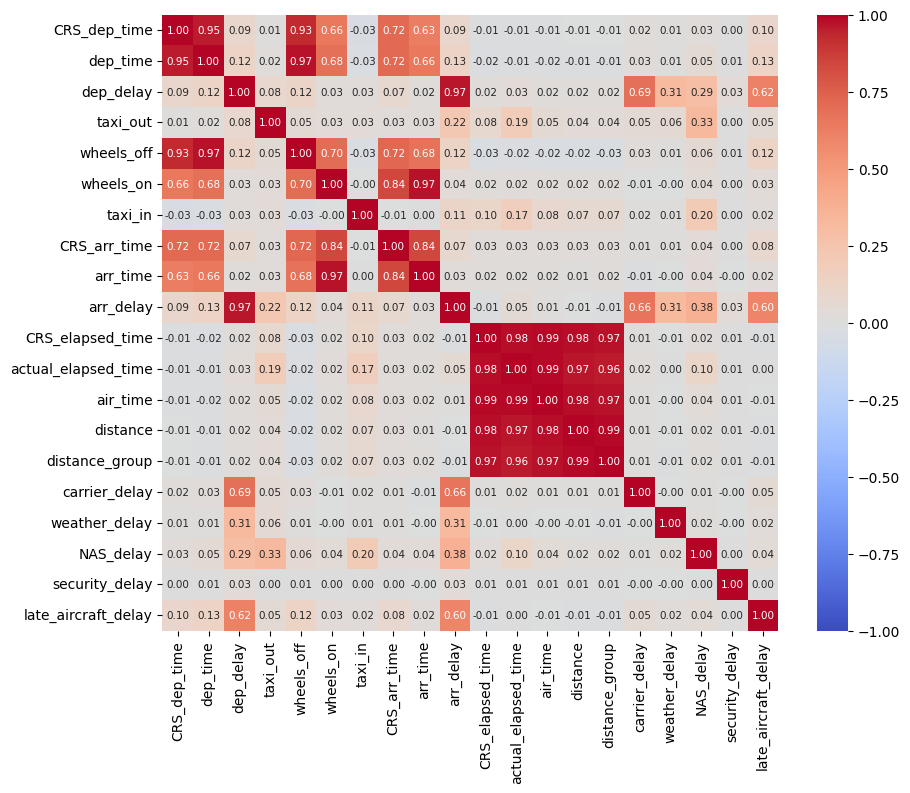

In [31]:
correlation_matrix = arr_delay.select_dtypes(include=['number']).corr()

plt.figure(figsize = (10,8))
sns.heatmap(correlation_matrix, cmap = 'coolwarm', vmax = 1.0, vmin = -1.0, annot = True, fmt = '.2f', 
            annot_kws = {'size':7.5}, square = True)

Arrival delay show a good correlation to carrier delay and slightly with weather delay, late aircraft delay & nas delay.
Arrival delay is heavily affected because of departure delay.
Remaining pair of variables with high correlation coefficients has to be ignored, because either they are derived features or timestamps.

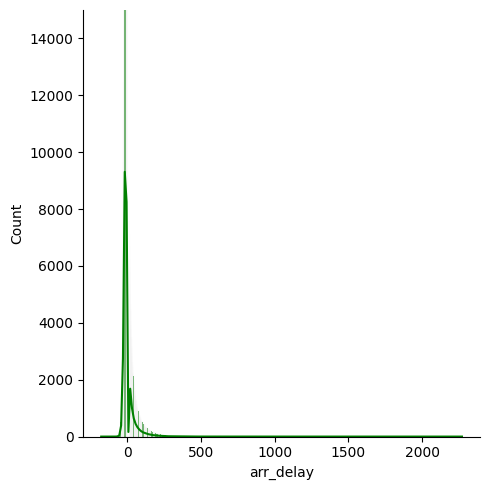

In [40]:
sns.displot(arr_delay['arr_delay'], color = 'g', kde = True)
plt.ylim(0,15000)
plt.show()

In [41]:
print("Skewness: %f" %arr_delay['arr_delay'].skew())
print("Kurtosis: %f" %arr_delay['arr_delay'].kurt())

Skewness: 8.832271
Kurtosis: 143.787544


From histogram and by skewness and kurtosis index, the departure delays are mostly located to the right side of the graph with a very long tail to the right. The majority of delays are short and the longer delays, while unusual are more heavyily loaded in time.

<Axes: xlabel='dep_delay', ylabel='arr_delay'>

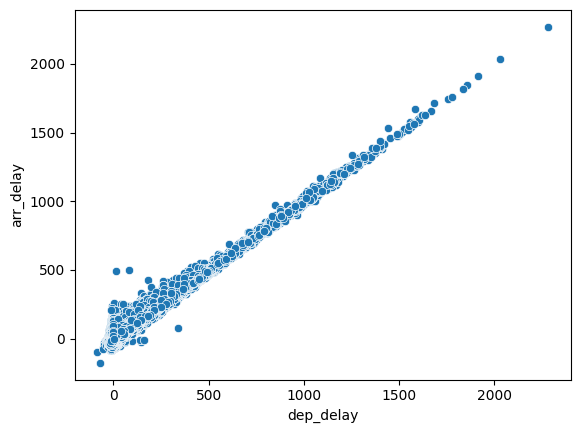

In [34]:
sns.scatterplot(data = arr_delay[['dep_delay','arr_delay']], x = 'dep_delay', y = 'arr_delay')

Correlation matrix had shown a strong relationship of departure and arrival delays. The above scatter plot illustrates the same.

Text(0.5, 1.0, 'Arrival Delay by Scheduled Arrival Time')

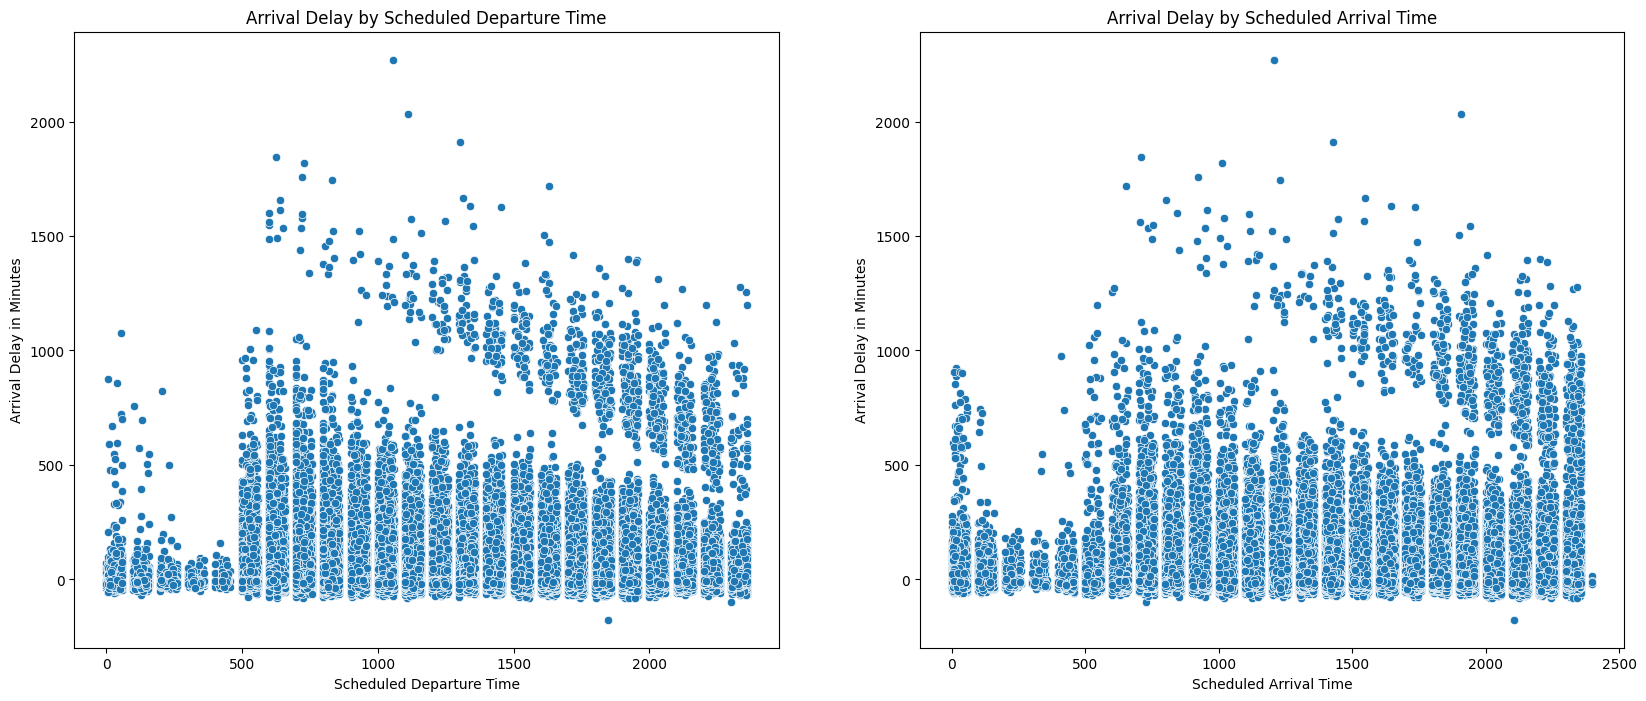

In [35]:
f, ax = plt.subplots(1, 2, figsize = (20,8))

sns.scatterplot(data = arr_delay, x = 'CRS_dep_time', y = 'arr_delay', ax = ax[0])
ax[0].set_xlabel('Scheduled Departure Time')
ax[0].set_ylabel('Arrival Delay in Minutes')
ax[0].set_title('Arrival Delay by Scheduled Departure Time')

sns.scatterplot(data = arr_delay, x = 'CRS_arr_time', y = 'arr_delay', ax = ax[1])
ax[1].set_xlabel('Scheduled Arrival Time')
ax[1].set_ylabel('Arrival Delay in Minutes')
ax[1].set_title('Arrival Delay by Scheduled Arrival Time')

C:\Users\karoo\AppData\Local\Temp\ipykernel_25244\2443850696.py:3: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(1,2,1)


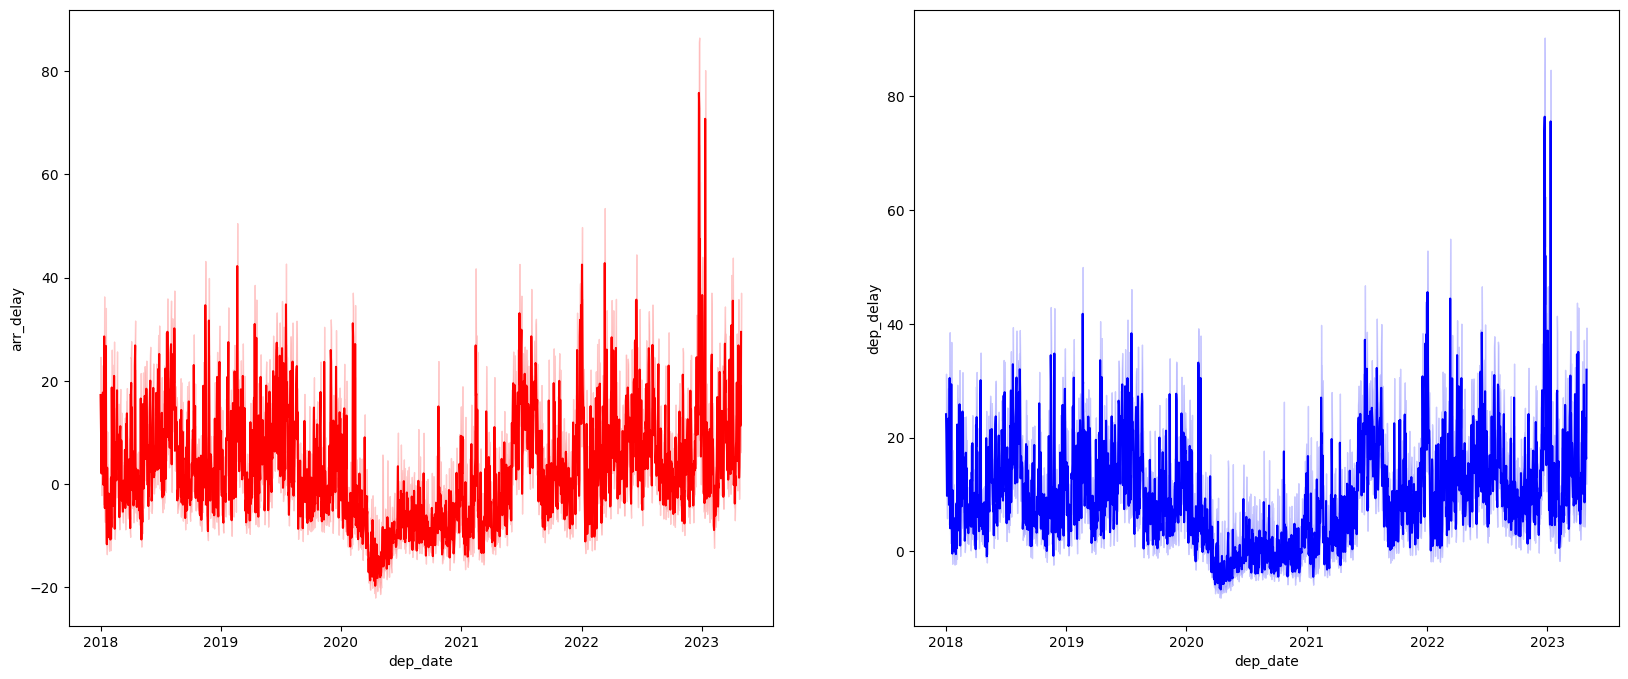

In [37]:
# do subplot for both arrival and departure delay over time
plt.subplots(figsize = (20,8))
plt.subplot(1,2,1)
sns.lineplot(data = arr_delay[['dep_date','arr_delay']], x = 'dep_date', y = 'arr_delay', color = 'r')
plt.subplot(1,2,2)
sns.lineplot(data = dep_delay[['dep_date', 'dep_delay']], x = 'dep_date', y = 'dep_delay', color = 'b')
plt.show()

The lineplot is same as departure delays through years.

Text(0.5, 1.0, 'Average minutes delayed by month')

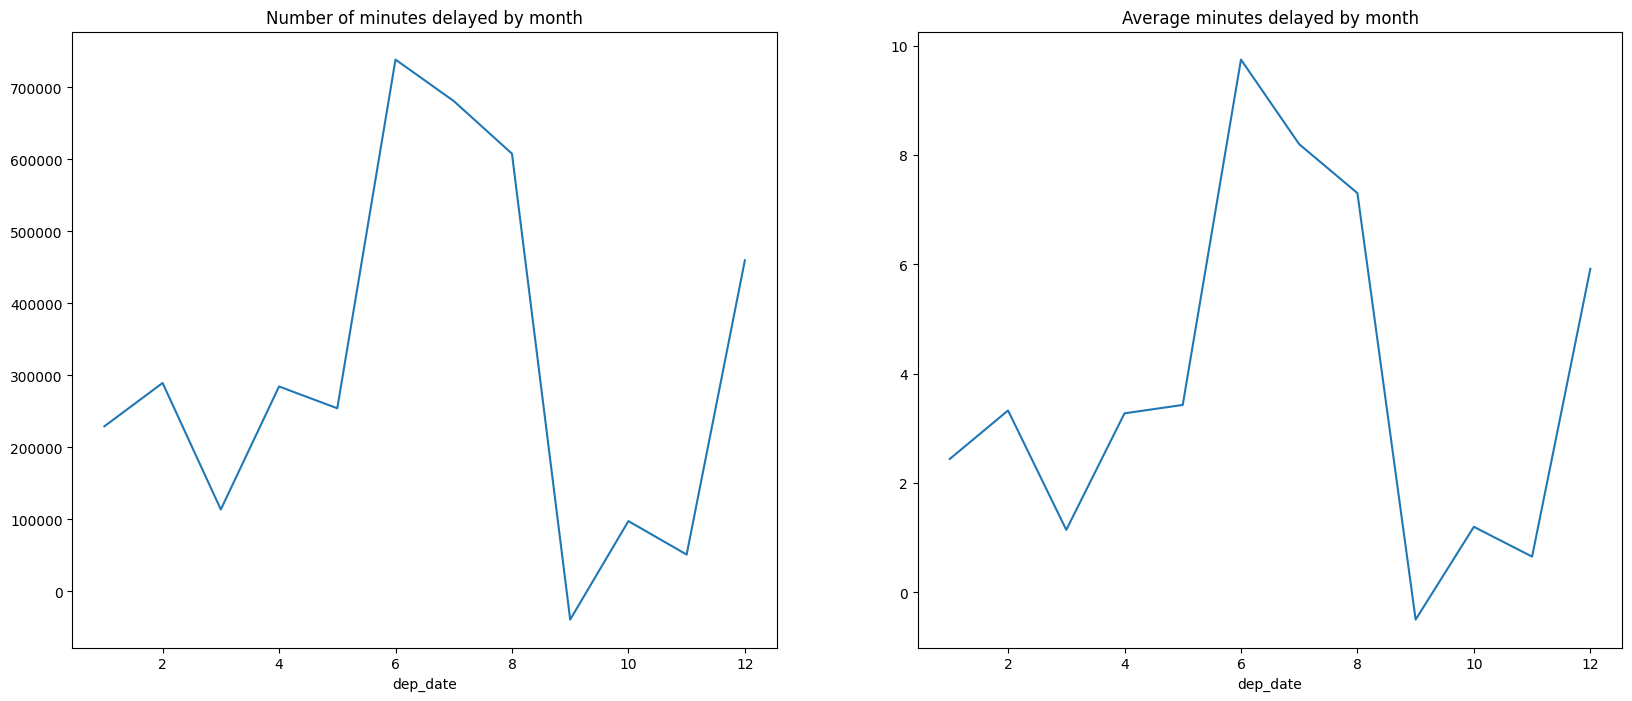

In [38]:
f, ax = plt.subplots(1, 2, figsize = (20,8))

arr_delay['arr_delay'].groupby(arr_delay.dep_date.dt.month).sum().plot(ax = ax[0])
ax[0].set_title('Number of minutes delayed by month')

arr_delay['arr_delay'].groupby(arr_delay.dep_date.dt.month).mean().plot(ax = ax[1])
ax[1].set_title('Average minutes delayed by month')

Average and total minutes of arrival delay are higher in the month of May to August and December.

## Components of Arrival Delay
- carrier delay
- Weather Delay
- Security Delay
- Late Aircraft Delay
- NAS delay

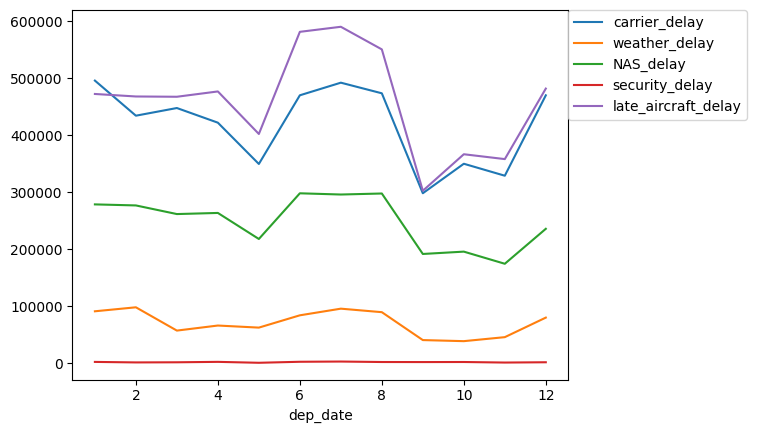

In [39]:
arr_delay[['carrier_delay', 'weather_delay', 'NAS_delay', 'security_delay', 'late_aircraft_delay']].groupby(arr_delay.dep_date.dt.month).sum().plot()

plt.legend(loc = 'upper left', bbox_to_anchor = (1, 1), borderaxespad = 0.0)
plt.show()

From the correlation matrix, it was intepreted that Carrier Delay, Weather Delay, LateAircraftDelay & NASDelay were main variables for arrival delay.